In [176]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

## Functions

In [208]:
def all_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'sigma', 'OOB_quantile', 'pb_i_cov', 'pb_ii_cov', 'pb_iii_cov', 'pb_iv_cov',
     'conf_i_cov', 'conf_ii_cov', 'conf_iii_cov', 'conf_iv_cov'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results')):
        if (file.endswith('.npy')):
            print(i)
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'sigma': file.split('_')[3][5:],
            'pb_i_cov': [result['pb_i_cov']],
            'pb_ii_cov': [result['pb_ii_cov']],
            'pb_iii_cov': [result['pb_iii_cov']],
            'pb_iv_cov': [result['pb_iv_cov']],
            'conf_i_cov': [result['conf_i_cov']],
            'conf_ii_cov': [result['conf_ii_cov']],
            'conf_iii_cov': [result['conf_iii_cov']],
            'conf_iv_cov': [result['conf_iv_cov']],
            'pb_mse': [result['pb_mse']],
            'conf_mse': [result['conf_mse']],
            'OOB_quantile': [result['OOB_quantile']],
            'quantile': [result['quantile']],
            'pb_time': [result['pb_time']],
            'conf_time': [result['conf_time']]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['sigma'] = coverage_df.sigma.astype('category')
    return coverage_df


# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
sigma_values = [0.7, 0.9, 1.4]  # Concentration parameters

Prediction balls

In [209]:
# Define confidence levels
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
coverage_df=all_coverage_results()
coverage_df.head()

0


KeyError: 'pb_mse'

In [179]:
def compute_summary(df):
    pb_grouped = df.groupby("train_size")["pb_time"].agg(["mean", "std"])
    conf_grouped = df.groupby("train_size")["conf_time"].agg(["mean", "std"])
    return {size: f"{row['mean']:.2f} ({row['std']:.2f})" for size, row in pb_grouped.iterrows()}, \
           {size: f"{row['mean']:.2f} ({row['std']:.2f})" for size, row in conf_grouped.iterrows()}

# Compute summaries for both methods
euc_summary, conf_summary = compute_summary(coverage_df)

# Get unique train sizes
train_sizes = sorted(set(coverage_df["train_size"]) | set(coverage_df["train_size"]))

# Construct DataFrame for LaTeX output
data = {
    size: [euc_summary.get(size, "-"), sc_summary.get(size, "-")] 
    for size in train_sizes
}
df_latex = pd.DataFrame(data, index=["Prediction Balls", "SC"])

# Generate LaTeX table
latex = df_latex.to_latex(
    index=True, column_format="l" + "c" * len(train_sizes),
    caption='Computation times for Prediction Balls and SC methods',
    label='tab:computation_times')

print(latex)

\begin{table}
\caption{Computation times for Prediction Balls and SC methods}
\label{tab:computation_times}
\begin{tabular}{lcccc}
\toprule
 & 50 & 100 & 200 & 500 \\
\midrule
Prediction Balls & 20.30 (1.65) & 21.09 (1.63) & 22.53 (1.77) & 25.57 (1.80) \\
SC & 19.63 (1.52) & 20.65 (1.49) & 21.37 (1.40) & 23.42 (1.50) \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_89168/2303784493.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pb_grouped = df.groupby("train_size")["pb_time"].agg(["mean", "std"])
/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_89168/2303784493.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_grouped = df.groupby("train_size")["conf_time"].agg(["mean", "std"])


# TYPE I

In [180]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(coverage_df, sample_sizes, sigma_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_i = {
    'sigma_0.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    #'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.4': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    conf_diccionario_i = {
    'sigma_0.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    #'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.4': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for sigma in sigma_values:
            pb_means = []
            conf_means = []
            coverage_df_N_sigma = coverage_df[(coverage_df['sigma'] == str(sigma)) 
            & (coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in coverage_df['i_cov']
                pb_row_data = coverage_df_N_sigma['pb_i_cov'].apply(lambda df: df[i])
                conf_row_data = coverage_df_N_sigma['conf_i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                pb_row_mean = pb_row_data.mean(axis=0)
                conf_row_mean = conf_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                pb_means.append(pb_row_mean)
                conf_means.append(conf_row_mean)

            pb_diccionario_i['sigma_' + str(sigma)][str(N)] = pb_means
            conf_diccionario_i['sigma_' + str(sigma)][str(N)] = conf_means

    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_i, conf_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
sigma_values = [0.7, 1.4]
pb_diccionario_i, conf_diccionario_i = calculate_type_i_coverage(coverage_df = coverage_df, sample_sizes = sample_sizes, sigma_values = sigma_values)
pb_diccionario_i

{'sigma_0.7': {'50': [array([0.984, 0.95 , 0.906]),
   array([0.976, 0.936, 0.876]),
   array([0.982, 0.946, 0.9  ]),
   array([0.988, 0.948, 0.882]),
   array([0.976, 0.938, 0.88 ]),
   array([0.986, 0.948, 0.886]),
   array([0.988, 0.956, 0.886]),
   array([0.974, 0.936, 0.894]),
   array([0.984, 0.934, 0.878]),
   array([0.99 , 0.96 , 0.908]),
   array([0.982, 0.95 , 0.88 ]),
   array([0.984, 0.94 , 0.886]),
   array([0.978, 0.946, 0.886]),
   array([0.984, 0.944, 0.87 ]),
   array([0.982, 0.942, 0.874]),
   array([0.988, 0.948, 0.884]),
   array([0.97 , 0.924, 0.864]),
   array([0.986, 0.938, 0.89 ]),
   array([0.978, 0.952, 0.868]),
   array([0.984, 0.934, 0.866]),
   array([0.982, 0.948, 0.892]),
   array([0.982, 0.944, 0.896]),
   array([0.984, 0.948, 0.88 ]),
   array([0.978, 0.934, 0.876]),
   array([0.98 , 0.94 , 0.868]),
   array([0.982, 0.946, 0.886]),
   array([0.986, 0.942, 0.898]),
   array([0.98 , 0.944, 0.888]),
   array([0.978, 0.946, 0.892]),
   array([0.986, 0.946, 

Prediction balls

In [181]:
# Prepare data for the DataFrame
pb_rows = []
index = []

for sigma in [0.7, 1.4]:
    for N in [50, 100, 200, 500]:
        pb_row = []
        pb_means = np.mean(pb_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0)
        pb_stds = np.sqrt(np.var(pb_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        pb_formatted_values = [f"{100*pb_means[i]:.2f} ({100*pb_stds[i]:.2f})" for i in range(3)]
        pb_row.extend(pb_formatted_values)
        pb_rows.append(pb_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
pb_df = pd.DataFrame(pb_rows, index=row_index, columns=col_index)

# Display the DataFrame
pb_df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.7   50            98.25 (0.52)  94.56 (0.94)  88.46 (1.26)
      100           98.00 (0.61)  94.23 (0.91)  89.14 (1.30)
      200           98.34 (0.59)  94.70 (0.83)  89.74 (0.91)
      500           98.81 (0.48)  94.92 (1.04)  89.97 (1.37)
1.4   50            97.78 (0.66)  94.13 (0.88)  88.09 (1.20)
      100           97.82 (0.50)  93.55 (0.98)  88.52 (1.22)
      200           98.41 (0.70)  94.29 (1.09)  89.26 (1.35)
      500           98.73 (0.48)  94.75 (1.05)  89.60 (1.47)

In [182]:
import pandas as pd
def format_cell(value):
    pb_mean, pb_std = value.split(" ")
    pb_mean = f"{float(pb_mean):.2f}"
    pb_std = pb_std.strip("()")
    pb_std = f"({float(pb_std):.2f})"
    return f"{pb_mean} {pb_std}"

# Apply formatting to all cells
pb_df = pb_df.applymap(format_cell)

pb_latex = pb_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:pbtypeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_89168/4181565808.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_df = pb_df.applymap(format_cell)


In [183]:
print(pb_latex)

\begin{table}
\caption{Type I error}
\label{tab:pbtypeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.7}} & \textbf{50} & 98.25 (0.52) & 94.56 (0.94) & 88.46 (1.26) \\
\textbf{} & \textbf{100} & 98.00 (0.61) & 94.23 (0.91) & 89.14 (1.30) \\
\textbf{} & \textbf{200} & 98.34 (0.59) & 94.70 (0.83) & 89.74 (0.91) \\
\textbf{} & \textbf{500} & 98.81 (0.48) & 94.92 (1.04) & 89.97 (1.37) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.4}} & \textbf{50} & 97.78 (0.66) & 94.13 (0.88) & 88.09 (1.20) \\
\textbf{} & \textbf{100} & 97.82 (0.50) & 93.55 (0.98) & 88.52 (1.22) \\
\textbf{} & \textbf{200} & 98.41 (0.70) & 94.29 (1.09) & 89.26 (1.35) \\
\textbf{} & \textbf{500} & 98.73 (0.48) & 94.75 (1.05) & 89.60 (1.47) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



Split-conformal

In [184]:
# Prepare data for the DataFrame
conf_rows = []
index = []

for sigma in [0.7, 1.4]:
    for N in [50, 100, 200, 500]:
        conf_row = []
        conf_means = np.mean(conf_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0)
        conf_stds = np.sqrt(np.var(conf_diccionario_i[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        conf_formatted_values = [f"{100*conf_means[i]:.2f} ({100*conf_stds[i]:.2f})" for i in range(3)]
        conf_row.extend(conf_formatted_values)
        conf_rows.append(conf_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
conf_df = pd.DataFrame(conf_rows, index=row_index, columns=col_index)

# Display the DataFrame
conf_df

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.7   50            96.22 (0.74)  92.73 (1.08)  89.20 (1.22)
      100           98.06 (0.60)  94.03 (1.09)  87.77 (1.48)
      200           98.10 (0.65)  94.15 (0.78)  89.26 (1.11)
      500           98.84 (0.49)  95.03 (0.96)  89.91 (1.55)
1.4   50            96.19 (0.77)  92.02 (1.07)  88.21 (1.18)
      100           97.84 (0.68)  94.06 (0.96)  88.55 (1.17)
      200           97.89 (0.68)  93.70 (1.26)  89.02 (1.54)
      500           98.72 (0.52)  94.82 (1.07)  89.32 (1.40)

In [185]:
import pandas as pd
def format_cell(value):
    conf_mean, conf_std = value.split(" ")
    conf_mean = f"{float(conf_mean):.2f}"
    conf_std = conf_std.strip("()")
    conf_std = f"({float(conf_std):.2f})"
    return f"{conf_mean} {conf_std}"

# Apply formatting to all cells
conf_df = conf_df.applymap(format_cell)

conf_latex = conf_df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:conftypeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_89168/2688314616.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_df = conf_df.applymap(format_cell)


In [186]:
print(conf_latex)

\begin{table}
\caption{Type I error}
\label{tab:conftypeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.7}} & \textbf{50} & 96.22 (0.74) & 92.73 (1.08) & 89.20 (1.22) \\
\textbf{} & \textbf{100} & 98.06 (0.60) & 94.03 (1.09) & 87.77 (1.48) \\
\textbf{} & \textbf{200} & 98.10 (0.65) & 94.15 (0.78) & 89.26 (1.11) \\
\textbf{} & \textbf{500} & 98.84 (0.49) & 95.03 (0.96) & 89.91 (1.55) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.4}} & \textbf{50} & 96.19 (0.77) & 92.02 (1.07) & 88.21 (1.18) \\
\textbf{} & \textbf{100} & 97.84 (0.68) & 94.06 (0.96) & 88.55 (1.17) \\
\textbf{} & \textbf{200} & 97.89 (0.68) & 93.70 (1.26) & 89.02 (1.54) \\
\textbf{} & \textbf{500} & 98.72 (0.52) & 94.82 (1.07) & 89.32 (1.40) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



# TYPE II

### sigma 0.7

In [187]:
ii_coverage_df_sigma_07_alpha_01 = coverage_df[coverage_df['sigma'] == '0.7'].copy()
ii_coverage_df_sigma_07_alpha_05 = coverage_df[coverage_df['sigma'] == '0.7'].copy()
ii_coverage_df_sigma_07_alpha_1  = coverage_df[coverage_df['sigma'] == '0.7'].copy()

ii_coverage_df_sigma_07_alpha_01['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['pb_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_07_alpha_01['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['conf_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_07_alpha_01['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.7']['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_sigma_07_alpha_01['quantile'] = coverage_df[coverage_df['sigma'] == '0.7']['quantile'].apply(lambda x: x[0])

ii_coverage_df_sigma_07_alpha_05['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['pb_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_07_alpha_05['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['conf_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_07_alpha_05['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.7']['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_sigma_07_alpha_05['quantile'] = coverage_df[coverage_df['sigma'] == '0.7']['quantile'].apply(lambda x: x[1])

ii_coverage_df_sigma_07_alpha_1['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['pb_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_07_alpha_1['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['conf_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_07_alpha_1['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '0.7']['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_sigma_07_alpha_1['quantile'] = coverage_df[coverage_df['sigma'] == '0.7']['quantile'].apply(lambda x: x[2])

ii_coverage_df_sigma_07_alpha_01.head()
ii_coverage_df_sigma_07_alpha_05.head()
ii_coverage_df_sigma_07_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
0,66,100,0.7,1.558385,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.914,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.948, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.926,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.934, 0.87, 0.766]",0.797169,0.978196,1.706980,18.878204,20.618258
2,328,200,0.7,1.250878,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.872,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.976, 0.794, 0.704]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.878,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.978, 0.95]",0.745416,0.997651,1.452764,22.315503,21.607145
4,315,100,0.7,1.664904,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.928,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.968, 0.952]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.900,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.976, 0.932]",0.864541,0.946923,1.658478,20.982059,21.769550
5,449,500,0.7,1.382848,"[[1.0, 1.0, 0.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.908,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.966, 0.936]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.878,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.944, 0.904]",0.848201,0.843994,1.295351,25.248579,28.263462
7,98,200,0.7,1.478677,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.878,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.966, 0.91]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.874,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.992, 0.964]",0.708847,0.912076,1.573012,20.680383,20.578261


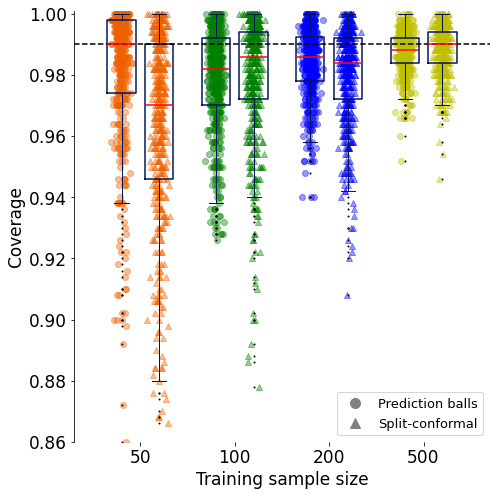

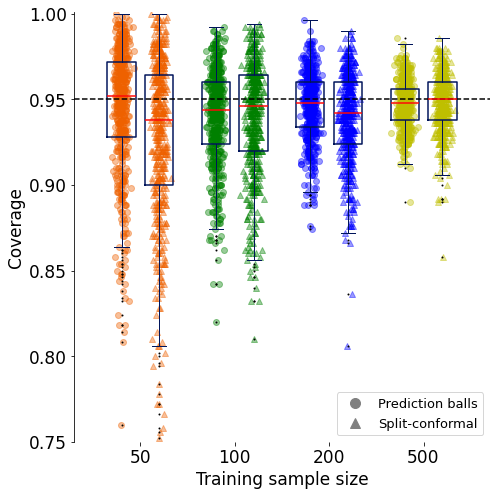

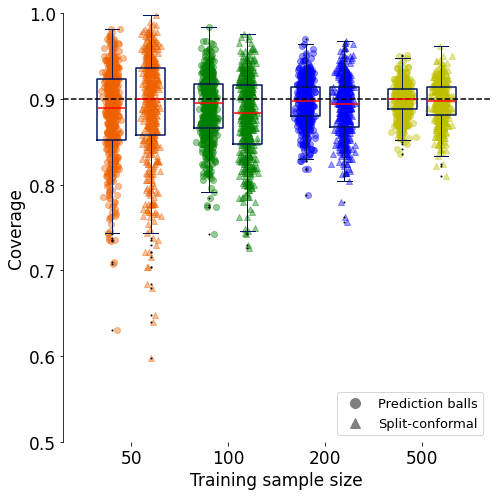

In [188]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [ii_coverage_df_sigma_07_alpha_01, ii_coverage_df_sigma_07_alpha_05, ii_coverage_df_sigma_07_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_ii_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_07_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 1.4

In [189]:
ii_coverage_df_sigma_14_alpha_01 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
ii_coverage_df_sigma_14_alpha_05 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
ii_coverage_df_sigma_14_alpha_1  = coverage_df[coverage_df['sigma'] == '1.4'].copy()

ii_coverage_df_sigma_14_alpha_01['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_14_alpha_01['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_14_alpha_01['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_sigma_14_alpha_01['quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['quantile'].apply(lambda x: x[0])

ii_coverage_df_sigma_14_alpha_05['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_14_alpha_05['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_14_alpha_05['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_sigma_14_alpha_05['quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['quantile'].apply(lambda x: x[1])

ii_coverage_df_sigma_14_alpha_1['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_14_alpha_1['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_14_alpha_1['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_sigma_14_alpha_1['quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['quantile'].apply(lambda x: x[2])

ii_coverage_df_sigma_14_alpha_01.head()
ii_coverage_df_sigma_14_alpha_05.head()
ii_coverage_df_sigma_14_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
1,301,100,1.4,3.043368,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.942,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.984, 0.96]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.946,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.976, 0.962]",2.746898,2.946758,3.259107,21.298351,19.554403
3,72,100,1.4,2.380634,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.874,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.998, 0.964, 0.882]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.900,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.998, 0.97, 0.928]",2.346303,2.674588,2.658663,20.520668,18.635047
6,363,100,1.4,2.748607,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.908,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.956, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.972,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.996, 0.988]",2.615833,2.534465,3.482207,21.609999,17.915152
8,96,50,1.4,3.095901,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.910,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.888, 0.808]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.748,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.952, 0.824]",3.134351,2.942007,2.004870,17.276607,19.867855
9,10,100,1.4,2.590674,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.864,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.992, 0.98, 0.946]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.806,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.962, 0.918]",2.428404,3.593248,2.595499,20.019028,17.129404


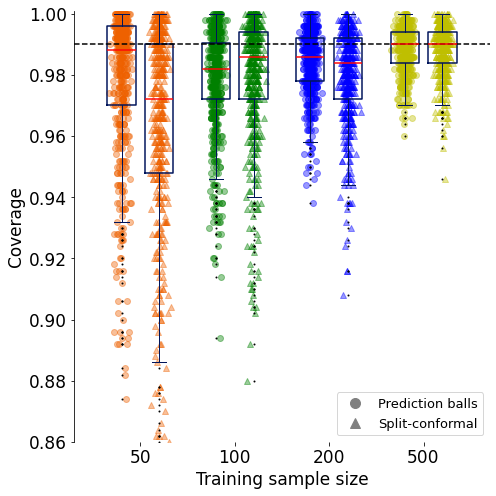

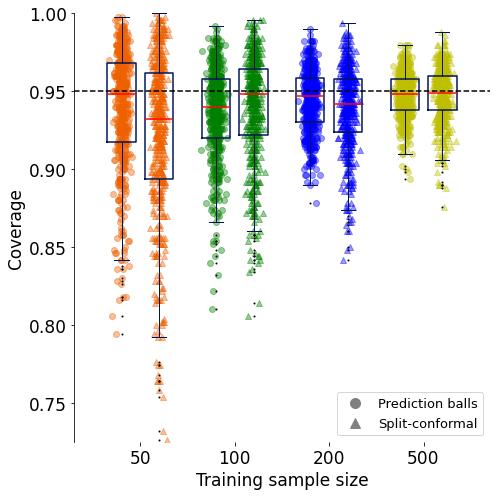

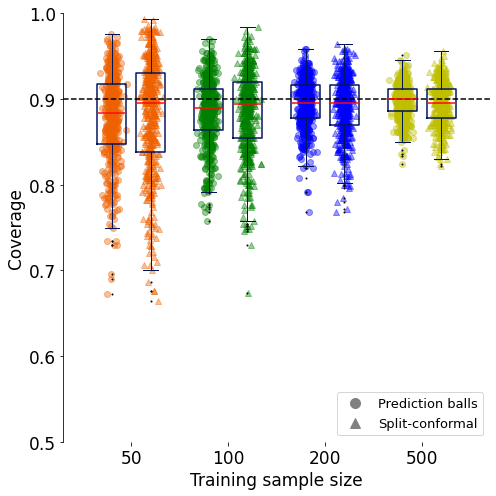

In [190]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [ii_coverage_df_sigma_14_alpha_01, ii_coverage_df_sigma_14_alpha_05, ii_coverage_df_sigma_14_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_ii_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.725, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_14_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 1.7

In [191]:
ii_coverage_df_sigma_14_alpha_01 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
ii_coverage_df_sigma_14_alpha_05 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
ii_coverage_df_sigma_14_alpha_1  = coverage_df[coverage_df['sigma'] == '1.4'].copy()

ii_coverage_df_sigma_14_alpha_01['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_14_alpha_01['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_ii_cov'].apply(lambda x: x[0])
ii_coverage_df_sigma_14_alpha_01['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_sigma_14_alpha_01['quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['quantile'].apply(lambda x: x[0])

ii_coverage_df_sigma_14_alpha_05['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_14_alpha_05['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_ii_cov'].apply(lambda x: x[1])
ii_coverage_df_sigma_14_alpha_05['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_sigma_14_alpha_05['quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['quantile'].apply(lambda x: x[1])

ii_coverage_df_sigma_14_alpha_1['pb_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_14_alpha_1['conf_ii_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_ii_cov'].apply(lambda x: x[2])
ii_coverage_df_sigma_14_alpha_1['OOB_quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_sigma_14_alpha_1['quantile'] = coverage_df[coverage_df['sigma'] == '1.4']['quantile'].apply(lambda x: x[2])

ii_coverage_df_sigma_14_alpha_01.head()
ii_coverage_df_sigma_14_alpha_05.head()
ii_coverage_df_sigma_14_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
1,301,100,1.4,3.043368,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.942,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.984, 0.96]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.946,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.976, 0.962]",2.746898,2.946758,3.259107,21.298351,19.554403
3,72,100,1.4,2.380634,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.874,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.998, 0.964, 0.882]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.900,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.998, 0.97, 0.928]",2.346303,2.674588,2.658663,20.520668,18.635047
6,363,100,1.4,2.748607,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.908,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.956, 0.92]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.972,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.996, 0.988]",2.615833,2.534465,3.482207,21.609999,17.915152
8,96,50,1.4,3.095901,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.910,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.888, 0.808]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.748,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.952, 0.824]",3.134351,2.942007,2.004870,17.276607,19.867855
9,10,100,1.4,2.590674,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.864,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.992, 0.98, 0.946]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.806,"[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.998, 0.962, 0.918]",2.428404,3.593248,2.595499,20.019028,17.129404


In [192]:
ii_coverage_df_alpha_01 = coverage_df.copy()
ii_coverage_df_alpha_05 = coverage_df.copy()
ii_coverage_df_alpha_1  = coverage_df.copy()

ii_coverage_df_alpha_01['OOB_quantile'] = coverage_df['OOB_quantile'].apply(lambda x: x[0])
ii_coverage_df_alpha_01['quantile'] = coverage_df['quantile'].apply(lambda x: x[0])

ii_coverage_df_alpha_05['OOB_quantile'] = coverage_df['OOB_quantile'].apply(lambda x: x[1])
ii_coverage_df_alpha_05['quantile'] = coverage_df['quantile'].apply(lambda x: x[1])

ii_coverage_df_alpha_1['OOB_quantile'] = coverage_df['OOB_quantile'].apply(lambda x: x[2])
ii_coverage_df_alpha_1['quantile'] = coverage_df['quantile'].apply(lambda x: x[2])

ii_coverage_df_alpha_01.head()
ii_coverage_df_alpha_05.head()
ii_coverage_df_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
0,66,100,0.7,1.558385,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.94, 0.914]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.948, 0.916]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.962, 0.926]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.934, 0.87, 0.766]",0.797169,0.978196,1.706980,18.878204,20.618258
1,301,100,1.4,3.043368,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.978, 0.942]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.984, 0.96]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.96, 0.946]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.976, 0.962]",2.746898,2.946758,3.259107,21.298351,19.554403
2,328,200,0.7,1.250878,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.994, 0.928, 0.872]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...","[0.976, 0.794, 0.704]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.956, 0.914, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.978, 0.95]",0.745416,0.997651,1.452764,22.315503,21.607145
3,72,100,1.4,2.380634,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.958, 0.874]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.998, 0.964, 0.882]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.9]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.998, 0.97, 0.928]",2.346303,2.674588,2.658663,20.520668,18.635047
4,315,100,0.7,1.664904,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.958, 0.928]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.968, 0.952]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.962, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.976, 0.932]",0.864541,0.946923,1.658478,20.982059,21.769550


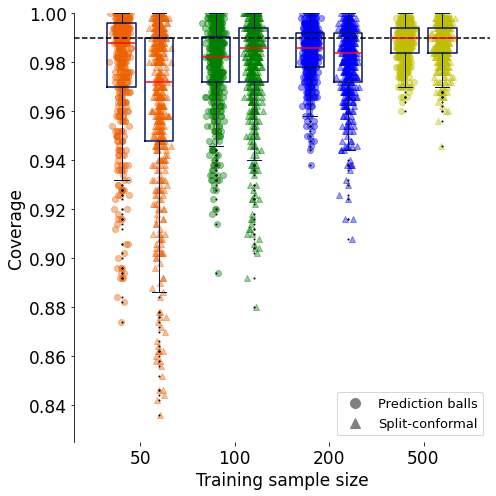

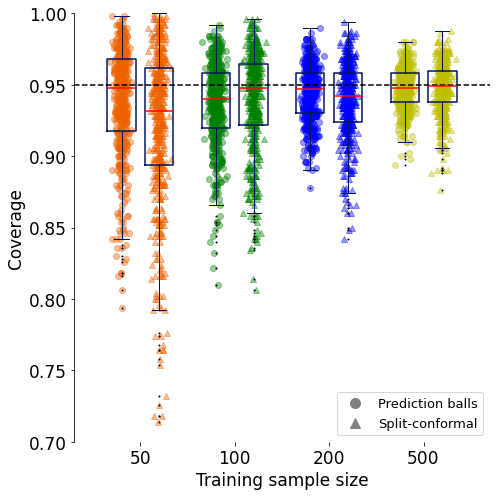

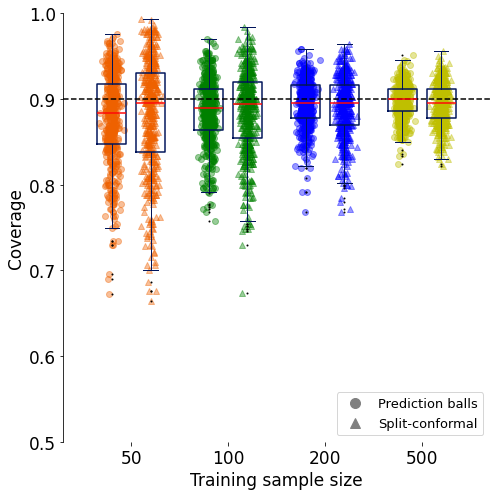

In [193]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [ii_coverage_df_sigma_14_alpha_01, ii_coverage_df_sigma_14_alpha_05, ii_coverage_df_sigma_14_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_ii_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_14_vs_II_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

0.7


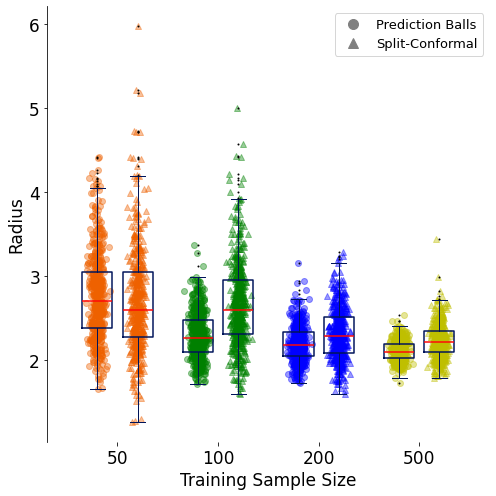

0.7


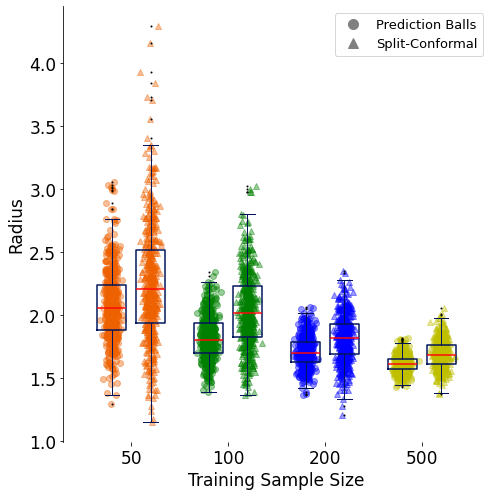

0.7


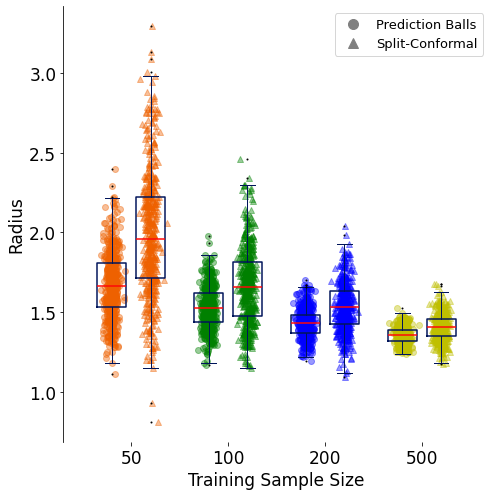

1.4


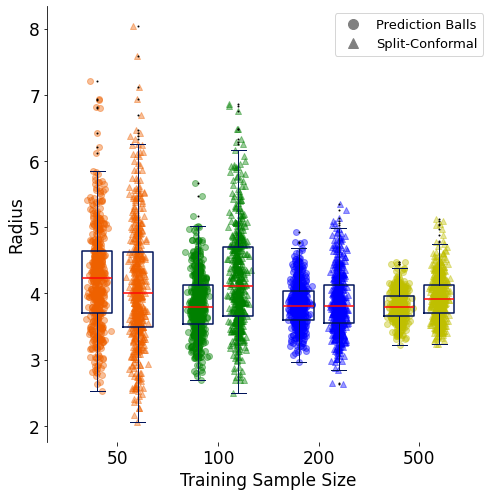

1.4


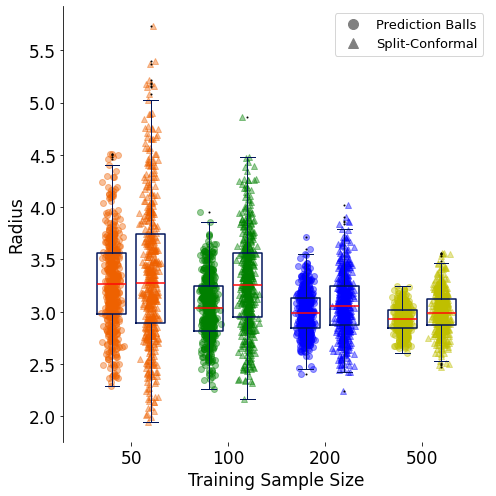

1.4


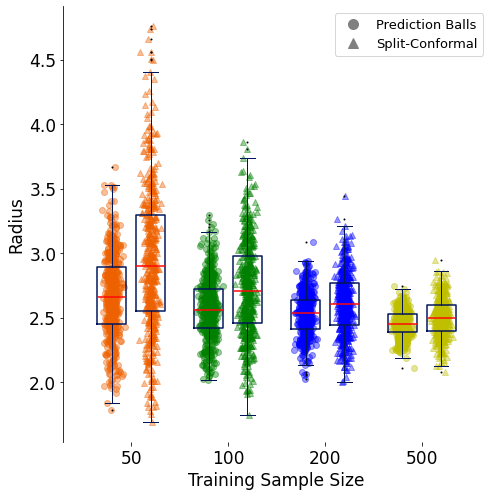

In [194]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def compare_pb_sc_radius(data_list, alpha_levels, sigmas, train_sizes, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) radius across different sigma and alpha values.

    Parameters:
        data_list (list): List of DataFrames containing radii for each alpha level.
        alpha_levels (list): List of significance levels (e.g., [0.01, 0.05, 0.1]).
        sigmas (list): List of sigma values to consider.
        train_sizes (list): List of training sample sizes.
        save_path (str): Path to save the generated plots.
    """
    
    ##### Set style options #####
    boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
    flierprops = dict(marker='o', markersize=1, linestyle='none')
    whiskerprops = dict(color='#00145A')
    capprops = dict(color='#00145A')
    medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

    # Iterate over sigma values
    for sigma in [0.7, 1.4]:
        for data, alpha in zip(data_list, alpha_levels):
            fig = plt.figure(facecolor="white", figsize=(7, 7))
            ax = fig.add_subplot(111)
            # Prepare boxplot data
            pb_boxplot_data = [
                data.loc[(data['sigma'] == str(sigma)) & (data['train_size'] == N), 'OOB_quantile']
                for N in train_sizes
            ]
            sc_boxplot_data = [
                data.loc[(data['sigma'] == str(sigma)) & (data['train_size'] == N), 'quantile']
                for N in train_sizes
            ]

            # Set positions for PB and SC boxplots
            positions_pb = np.array(range(len(train_sizes))) - 0.2
            positions_sc = np.array(range(len(train_sizes))) + 0.2
            # Boxplots for PB and SC
            ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)
            
            ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                       boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                       flierprops=flierprops, medianprops=medianprops, showmeans=False)

            # Scatter plot
            palette = ['#ee6100', 'g', 'b', 'y']  # Colors for each N

            for i, N in enumerate(train_sizes):
                xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
                xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))
                ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
                ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")

            sns.despine(bottom=True)  # Remove right and top axis lines

            ax.set_xticks(range(len(train_sizes)))
            ax.set_xticklabels([str(N) for N in train_sizes], fontsize=17)

            ax.set_xlabel('Training Sample Size', fontsize=17)
            ax.set_ylabel('Radius', fontsize=17)
            ax.tick_params(labelsize=17)
            ax.grid(False)
        
            # Legend
            legend_handles = [
                mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
                mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
            ]
            ax.legend(handles=legend_handles, loc='upper right', fontsize=13)

            fig.tight_layout()
            filename = os.path.join(save_path, f'simulations_euc/pb_vs_conf_radius_vs_sigma_{sigma}_alpha_{str(alpha)[2:]}.pdf')
            fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
            print(sigma)
            plt.show()

compare_pb_sc_radius(
    data_list = [ii_coverage_df_alpha_01, ii_coverage_df_alpha_05, ii_coverage_df_alpha_1],
    alpha_levels=[0.01, 0.05, 0.1],
    sigmas=[0.9],  # Modify as needed
    train_sizes=[50, 100, 200, 500],
    save_path=os.getcwd()  # Change to desired directory
)

# TYPE III

In [195]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(coverage_df, sample_sizes, sigma_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_iii = {
    'sigma_0.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    #'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.4': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    conf_diccionario_iii = {
    'sigma_0.7': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    #'sigma_0.9': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'sigma_1.4': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for sigma in sigma_values:
            pb_means = []
            conf_means = []
            coverage_df_N_sigma = coverage_df[(coverage_df['sigma'] == str(sigma)) 
            & (coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(50):
                # Extract the i-th row from each 50x3 DataFrame in coverage_df['i_cov']
                pb_row_data = coverage_df_N_sigma['pb_iii_cov'].apply(lambda df: df[i])
                conf_row_data = coverage_df_N_sigma['conf_iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                pb_row_mean = pb_row_data.mean(axis=0)
                conf_row_mean = conf_row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                pb_means.append(pb_row_mean)
                conf_means.append(conf_row_mean)

            pb_diccionario_iii['sigma_' + str(sigma)][str(N)] = pb_means
            conf_diccionario_iii['sigma_' + str(sigma)][str(N)] = conf_means

    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_iii, conf_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
sigma_values = [0.7, 1.4]
pb_diccionario_iii, conf_diccionario_iii = calculate_type_iii_coverage(coverage_df = coverage_df, sample_sizes = sample_sizes, sigma_values = sigma_values)
pb_diccionario_iii

{'sigma_0.7': {'50': [array([0.992, 0.968, 0.932]),
   array([0.992, 0.976, 0.934]),
   array([0.992, 0.968, 0.94 ]),
   array([0.996, 0.978, 0.93 ]),
   array([0.996, 0.972, 0.934]),
   array([0.998, 0.982, 0.94 ]),
   array([0.998, 0.976, 0.922]),
   array([1.   , 0.992, 0.96 ]),
   array([0.99 , 0.974, 0.922]),
   array([0.994, 0.976, 0.946]),
   array([0.998, 0.976, 0.94 ]),
   array([0.998, 0.982, 0.942]),
   array([0.996, 0.982, 0.954]),
   array([0.996, 0.976, 0.926]),
   array([0.996, 0.976, 0.928]),
   array([0.998, 0.982, 0.94 ]),
   array([0.998, 0.988, 0.948]),
   array([0.996, 0.976, 0.918]),
   array([0.998, 0.986, 0.946]),
   array([0.994, 0.978, 0.948]),
   array([0.99, 0.97, 0.95]),
   array([0.992, 0.984, 0.94 ]),
   array([0.994, 0.966, 0.934]),
   array([0.99 , 0.978, 0.944]),
   array([0.998, 0.966, 0.926]),
   array([0.996, 0.98 , 0.932]),
   array([0.996, 0.98 , 0.938]),
   array([0.994, 0.978, 0.938]),
   array([0.996, 0.97 , 0.936]),
   array([0.994, 0.974, 0.9

Prediction balls

In [196]:
# Prepare data for the DataFrame
pb_rows = []
index = []

for sigma in [0.7, 1.4]:
    for N in [50, 100, 200, 500]:
        pb_row = []
        pb_means = np.mean(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        pb_stds = np.sqrt(np.var(pb_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        pb_formatted_values = [f"{100*pb_means[i]:.2f} ({100*pb_stds[i]:.2f})" for i in range(3)]
        pb_row.extend(pb_formatted_values)
        pb_rows.append(pb_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(pb_rows, index=row_index, columns=col_index)

# Display the DataFrame
pb_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.7   50            99.49 (0.34)  97.70 (0.62)  93.70 (0.94)
      100           99.12 (0.48)  96.63 (0.87)  92.90 (1.10)
      200           99.12 (0.37)  96.29 (0.70)  92.02 (1.18)
      500           99.22 (0.47)  95.85 (0.91)  91.43 (1.26)
1.4   50            98.64 (0.40)  95.64 (0.79)  90.15 (1.26)
      100           98.44 (0.53)  94.98 (0.89)  90.35 (1.37)
      200           98.76 (0.52)  95.28 (1.02)  90.66 (1.44)
      500           98.90 (0.41)  95.23 (0.81)  90.50 (1.18)

In [197]:
import pandas as pd
def format_cell(value):
    pb_mean, pb_std = value.split(" ")
    pb_mean = f"{float(pb_mean):.2f}"
    pb_std = pb_std.strip("()")
    pb_std = f"({float(pb_std):.2f})"
    return f"{pb_mean} {pb_std}"

# Apply formatting to all cells
pb_df_iii = pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:pbtypeIIIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_89168/2124976488.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_df_iii = pb_df_iii.applymap(format_cell)


In [198]:
print(pb_latex_iii)

\begin{table}
\caption{Type III error}
\label{tab:pbtypeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.7}} & \textbf{50} & 99.49 (0.34) & 97.70 (0.62) & 93.70 (0.94) \\
\textbf{} & \textbf{100} & 99.12 (0.48) & 96.63 (0.87) & 92.90 (1.10) \\
\textbf{} & \textbf{200} & 99.12 (0.37) & 96.29 (0.70) & 92.02 (1.18) \\
\textbf{} & \textbf{500} & 99.22 (0.47) & 95.85 (0.91) & 91.43 (1.26) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.4}} & \textbf{50} & 98.64 (0.40) & 95.64 (0.79) & 90.15 (1.26) \\
\textbf{} & \textbf{100} & 98.44 (0.53) & 94.98 (0.89) & 90.35 (1.37) \\
\textbf{} & \textbf{200} & 98.76 (0.52) & 95.28 (1.02) & 90.66 (1.44) \\
\textbf{} & \textbf{500} & 98.90 (0.41) & 95.23 (0.81) & 90.50 (1.18) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



Split-conformal

In [199]:
# Prepare data for the DataFrame
conf_rows = []
index = []

for sigma in [0.7, 1.4]:
    for N in [50, 100, 200, 500]:
        conf_row = []
        conf_means = np.mean(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0)
        conf_stds = np.sqrt(np.var(conf_diccionario_iii[f'sigma_{sigma}'][str(N)], axis=0))
        # Format as "mean (std)"
        conf_formatted_values = [f"{100*conf_means[i]:.2f} ({100*conf_stds[i]:.2f})" for i in range(3)]
        conf_row.extend(conf_formatted_values)
        conf_rows.append(conf_row)
        index.append((f"{sigma}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["sigma", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
conf_df_iii = pd.DataFrame(conf_rows, index=row_index, columns=col_index)

# Display the DataFrame
conf_df_iii

Significance Level          0.01          0.05           0.1
sigma N                                                     
0.7   50            98.81 (0.50)  96.98 (0.72)  94.94 (0.95)
      100           99.42 (0.39)  97.41 (0.68)  93.41 (1.07)
      200           99.07 (0.42)  96.56 (0.79)  93.12 (1.08)
      500           99.30 (0.39)  96.37 (1.01)  92.05 (1.28)
1.4   50            97.42 (0.58)  94.40 (0.97)  91.05 (1.04)
      100           98.53 (0.50)  95.38 (0.90)  90.62 (1.27)
      200           98.38 (0.56)  94.84 (1.04)  90.56 (1.35)
      500           99.00 (0.42)  95.27 (0.91)  90.50 (1.04)

In [200]:
import pandas as pd
def format_cell(value):
    conf_mean, conf_std = value.split(" ")
    conf_mean = f"{float(conf_mean):.2f}"
    conf_std = conf_std.strip("()")
    conf_std = f"({float(conf_std):.2f})"
    return f"{conf_mean} {conf_std}"

# Apply formatting to all cells
conf_df_iii = conf_df_iii.applymap(format_cell)

conf_latex_iii = conf_df_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type III error', label='tab:conftypeIIIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_89168/998839332.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  conf_df_iii = conf_df_iii.applymap(format_cell)


In [201]:
print(conf_latex_iii)

\begin{table}
\caption{Type III error}
\label{tab:conftypeIIIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
sigma & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{0.7}} & \textbf{50} & 98.81 (0.50) & 96.98 (0.72) & 94.94 (0.95) \\
\textbf{} & \textbf{100} & 99.42 (0.39) & 97.41 (0.68) & 93.41 (1.07) \\
\textbf{} & \textbf{200} & 99.07 (0.42) & 96.56 (0.79) & 93.12 (1.08) \\
\textbf{} & \textbf{500} & 99.30 (0.39) & 96.37 (1.01) & 92.05 (1.28) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{1.4}} & \textbf{50} & 97.42 (0.58) & 94.40 (0.97) & 91.05 (1.04) \\
\textbf{} & \textbf{100} & 98.53 (0.50) & 95.38 (0.90) & 90.62 (1.27) \\
\textbf{} & \textbf{200} & 98.38 (0.56) & 94.84 (1.04) & 90.56 (1.35) \\
\textbf{} & \textbf{500} & 99.00 (0.42) & 95.27 (0.91) & 90.50 (1.04) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



# Type IV

### sigma 0.7

In [202]:
iv_coverage_df_sigma_07_alpha_01 = coverage_df[coverage_df['sigma'] == '0.7'].copy()
iv_coverage_df_sigma_07_alpha_05 = coverage_df[coverage_df['sigma'] == '0.7'].copy()
iv_coverage_df_sigma_07_alpha_1  = coverage_df[coverage_df['sigma'] == '0.7'].copy()

iv_coverage_df_sigma_07_alpha_01['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['pb_iv_cov'].apply(lambda x: x[0])
iv_coverage_df_sigma_07_alpha_01['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['conf_iv_cov'].apply(lambda x: x[0])

iv_coverage_df_sigma_07_alpha_05['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['pb_iv_cov'].apply(lambda x: x[1])
iv_coverage_df_sigma_07_alpha_05['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['conf_iv_cov'].apply(lambda x: x[1])

iv_coverage_df_sigma_07_alpha_1['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['pb_iv_cov'].apply(lambda x: x[2])
iv_coverage_df_sigma_07_alpha_1['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '0.7']['conf_iv_cov'].apply(lambda x: x[2])

iv_coverage_df_sigma_07_alpha_01.head()
iv_coverage_df_sigma_07_alpha_05.head()
iv_coverage_df_sigma_07_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
0,66,100,0.7,"[2.154405909867627, 1.757079703199621, 1.55838...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.94, 0.914]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.916,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.962, 0.926]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.766,0.797169,0.978196,"[2.2905084936746447, 1.9721340155926868, 1.706...",18.878204,20.618258
2,328,200,0.7,"[2.2721581058548597, 1.4238151764757117, 1.250...","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.994, 0.928, 0.872]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 0.0, ...",0.704,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.956, 0.914, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.950,0.745416,0.997651,"[2.0256968559081967, 1.6460972276884605, 1.452...",22.315503,21.607145
4,315,100,0.7,"[2.4373807449329488, 1.7978715968720675, 1.664...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.958, 0.928]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.952,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.962, 0.9]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.932,0.864541,0.946923,"[2.742905730206343, 2.1104865109857687, 1.6584...",20.982059,21.769550
5,449,500,0.7,"[2.2450458717208726, 1.5692627202317502, 1.382...","[[1.0, 1.0, 0.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[0.992, 0.93, 0.908]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.936,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.926, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.904,0.848201,0.843994,"[1.949278311069752, 1.4744634227048703, 1.2953...",25.248579,28.263462
7,98,200,0.7,"[2.63860548057736, 1.8177132501186373, 1.47867...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.994, 0.936, 0.878]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.910,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.918, 0.874]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.964,0.708847,0.912076,"[2.642487254640946, 1.9048178625001322, 1.5730...",20.680383,20.578261


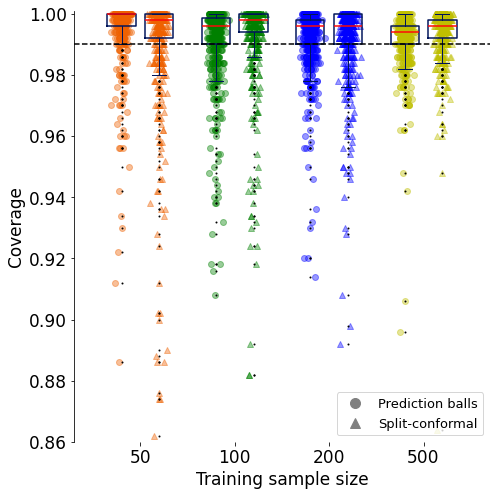

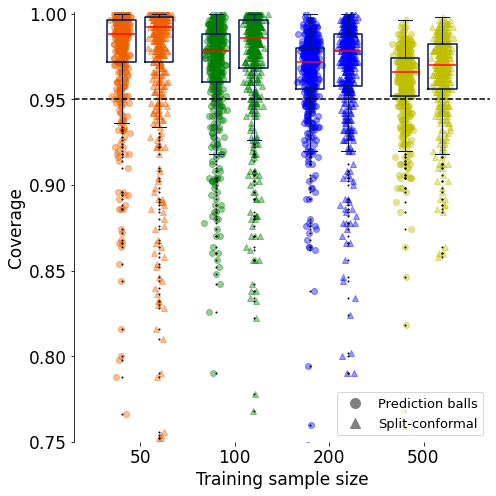

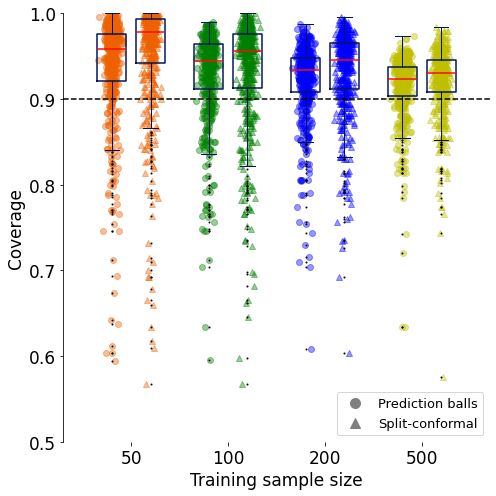

In [203]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [iv_coverage_df_sigma_07_alpha_01, iv_coverage_df_sigma_07_alpha_05, iv_coverage_df_sigma_07_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_iv_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.75, 1.001)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_07_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 1.4

In [204]:
iv_coverage_df_sigma_14_alpha_01 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
iv_coverage_df_sigma_14_alpha_05 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
iv_coverage_df_sigma_14_alpha_1  = coverage_df[coverage_df['sigma'] == '1.4'].copy()

iv_coverage_df_sigma_14_alpha_01['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_iv_cov'].apply(lambda x: x[0])
iv_coverage_df_sigma_14_alpha_01['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_iv_cov'].apply(lambda x: x[0])

iv_coverage_df_sigma_14_alpha_05['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_iv_cov'].apply(lambda x: x[1])
iv_coverage_df_sigma_14_alpha_05['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_iv_cov'].apply(lambda x: x[1])

iv_coverage_df_sigma_14_alpha_1['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_iv_cov'].apply(lambda x: x[2])
iv_coverage_df_sigma_14_alpha_1['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_iv_cov'].apply(lambda x: x[2])

iv_coverage_df_sigma_14_alpha_01.head()
iv_coverage_df_sigma_14_alpha_05.head()
iv_coverage_df_sigma_14_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
1,301,100,1.4,"[3.892380369010213, 3.5702135337892114, 3.0433...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.978, 0.942]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.960,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.96, 0.946]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.962,2.746898,2.946758,"[5.624852387141109, 3.5732442629857277, 3.2591...",21.298351,19.554403
3,72,100,1.4,"[4.339508627817734, 3.1452716048965232, 2.3806...","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.958, 0.874]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.882,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.9]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.928,2.346303,2.674588,"[4.319375018620427, 3.2549632684901084, 2.6586...",20.520668,18.635047
6,363,100,1.4,"[4.428036830277929, 3.3032640749556625, 2.7486...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.958, 0.908]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.920,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[1.0, 0.996, 0.972]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.988,2.615833,2.534465,"[5.711685332121991, 4.064400621101833, 3.48220...",21.609999,17.915152
8,96,50,1.4,"[4.64699814203211, 3.4724344601691732, 3.09590...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.938, 0.91]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.808,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.892, 0.748]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.824,3.134351,2.942007,"[4.423145414633938, 2.8193208697372927, 2.0048...",17.276607,19.867855
9,10,100,1.4,"[3.799223913734309, 3.281516765051534, 2.59067...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.956, 0.864]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.946,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.858, 0.806]","[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.918,2.428404,3.593248,"[4.592585577229112, 2.983299847085343, 2.59549...",20.019028,17.129404


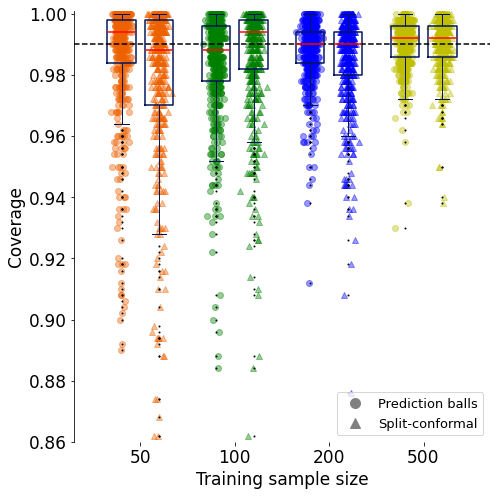

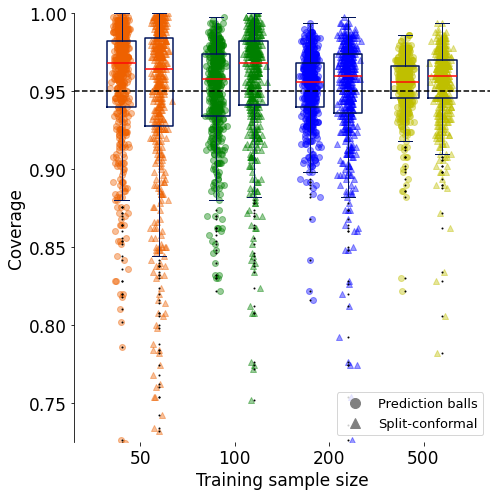

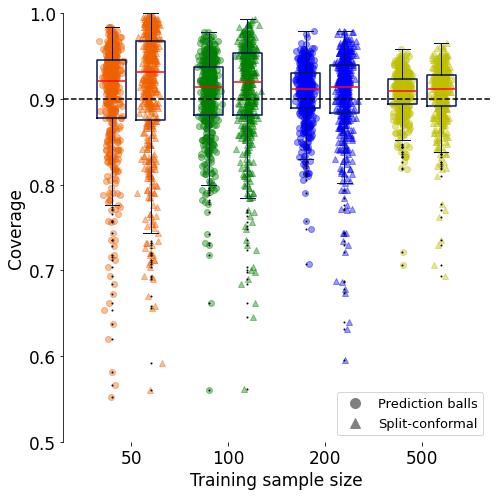

In [205]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [iv_coverage_df_sigma_14_alpha_01, iv_coverage_df_sigma_14_alpha_05, iv_coverage_df_sigma_14_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_iv_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.86, 1.001)
    elif alpha_level == 0.05:
        ax.set_ylim(0.725, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_14_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

### sigma 1.4

In [206]:
iv_coverage_df_sigma_14_alpha_01 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
iv_coverage_df_sigma_14_alpha_05 = coverage_df[coverage_df['sigma'] == '1.4'].copy()
iv_coverage_df_sigma_14_alpha_1  = coverage_df[coverage_df['sigma'] == '1.4'].copy()

iv_coverage_df_sigma_14_alpha_01['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_iv_cov'].apply(lambda x: x[0])
iv_coverage_df_sigma_14_alpha_01['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_iv_cov'].apply(lambda x: x[0])

iv_coverage_df_sigma_14_alpha_05['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_iv_cov'].apply(lambda x: x[1])
iv_coverage_df_sigma_14_alpha_05['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_iv_cov'].apply(lambda x: x[1])

iv_coverage_df_sigma_14_alpha_1['pb_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['pb_iv_cov'].apply(lambda x: x[2])
iv_coverage_df_sigma_14_alpha_1['conf_iv_cov']  = coverage_df[coverage_df['sigma'] == '1.4']['conf_iv_cov'].apply(lambda x: x[2])

iv_coverage_df_sigma_14_alpha_01.head()
iv_coverage_df_sigma_14_alpha_05.head()
iv_coverage_df_sigma_14_alpha_1.head()

,sample_index,train_size,sigma,OOB_quantile,pb_i_cov,pb_ii_cov,pb_iii_cov,pb_iv_cov,conf_i_cov,conf_ii_cov,conf_iii_cov,conf_iv_cov,pb_mse,conf_mse,quantile,pb_time,conf_time
1,301,100,1.4,"[3.892380369010213, 3.5702135337892114, 3.0433...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.978, 0.942]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.960,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.96, 0.946]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.962,2.746898,2.946758,"[5.624852387141109, 3.5732442629857277, 3.2591...",21.298351,19.554403
3,72,100,1.4,"[4.339508627817734, 3.1452716048965232, 2.3806...","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.958, 0.874]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.882,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.958, 0.9]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.928,2.346303,2.674588,"[4.319375018620427, 3.2549632684901084, 2.6586...",20.520668,18.635047
6,363,100,1.4,"[4.428036830277929, 3.3032640749556625, 2.7486...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.996, 0.958, 0.908]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.920,"[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...","[1.0, 0.996, 0.972]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.988,2.615833,2.534465,"[5.711685332121991, 4.064400621101833, 3.48220...",21.609999,17.915152
8,96,50,1.4,"[4.64699814203211, 3.4724344601691732, 3.09590...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.988, 0.938, 0.91]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.808,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.986, 0.892, 0.748]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.824,3.134351,2.942007,"[4.423145414633938, 2.8193208697372927, 2.0048...",17.276607,19.867855
9,10,100,1.4,"[3.799223913734309, 3.281516765051534, 2.59067...","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.98, 0.956, 0.864]","[[1.0, 1.0, 1.0], [1.0, 1.0, 0.0], [1.0, 1.0, ...",0.946,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.858, 0.806]","[[1.0, 1.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.918,2.428404,3.593248,"[4.592585577229112, 2.983299847085343, 2.59549...",20.019028,17.129404


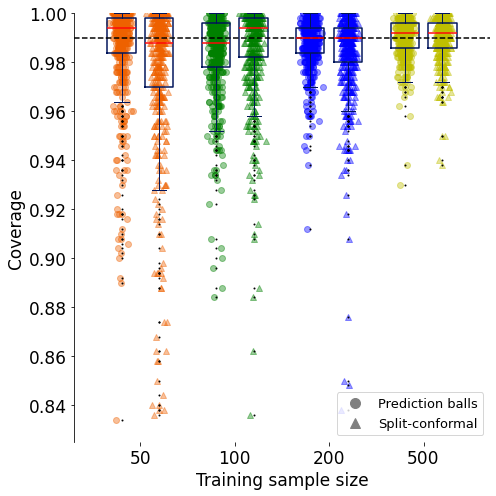

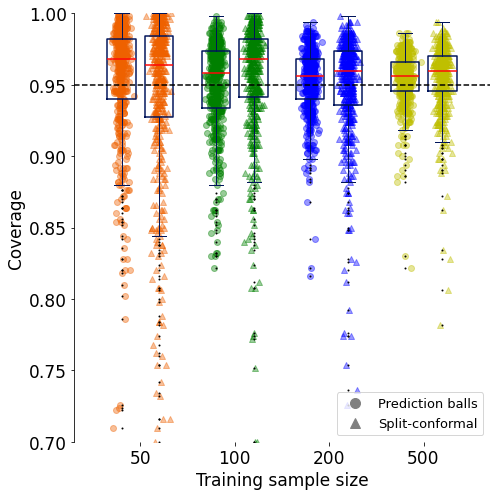

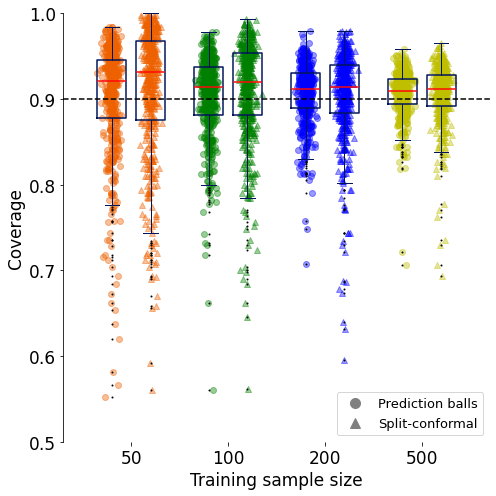

In [207]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for sigma_data, alpha_level in zip(
    [iv_coverage_df_sigma_14_alpha_01, iv_coverage_df_sigma_14_alpha_05, iv_coverage_df_sigma_14_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    pb_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['pb_iv_cov'].values for size in train_sizes]
    conf_sigma_boxplot_data = [sigma_data[sigma_data['train_size'] == size]['conf_iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    pb_positions_sigma = np.array(range(len(train_sizes))) - 0.2
    conf_positions_sigma = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(pb_sigma_boxplot_data, positions=pb_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(conf_sigma_boxplot_data, positions=conf_positions_sigma, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               flierprops=dict(marker='o', markersize=1, linestyle='none'), 
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    pb_palette_sigma = ['#ee6100', 'g', 'b', 'y']
    conf_palette_sigma = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        pb_xs_sigma = np.random.normal(pb_positions_sigma[i], 0.04, len(pb_sigma_boxplot_data[i]))
        conf_xs_sigma = np.random.normal(conf_positions_sigma[i], 0.04, len(conf_sigma_boxplot_data[i]))

        ax.scatter(pb_xs_sigma, pb_sigma_boxplot_data[i], alpha=0.4, color = pb_palette_sigma[i], label='Prediction balls')
        ax.scatter(conf_xs_sigma, conf_sigma_boxplot_data[i], alpha=0.4, color = conf_palette_sigma[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    legend_handles = [
        mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction balls'),
        mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-conformal')
    ]

    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)
    fig.tight_layout()
    filename = os.path.join(os.getcwd(), f'simulations_euc/pb_vs_conf_sigma_14_vs_IV_coverage_{str(alpha_level)[2:]}.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()